In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("sci.mplstyle")

In [2]:
def tinh_he_so_forward(kappa, C, rho, N_x, N_time, L, t_max):
    h = L / (N_x - 1) # buoc luoi khong gian
    k = t_max / (N_time - 1) # buoc luoi thoi gian

    alpha = np.sqrt(kappa / (C * rho)) #  he so khuech tan nhiet

    eta = alpha**2 * k / h**2 # he so on dinh

    if eta > 0.5:
        print(f"So do Forward Euler khong on dinh: eta = {eta:.6f} > 0.5")
        print("Hay tang N_time hoac giam N_x.")
        return None

    return eta, h, k, alpha

In [3]:
def ham_ghi_file(file, dk_bai_toan): # dung de ghi thong tin quan trong ra file

    file.write(f"# {dk_bai_toan['mo_ta']}\n")
    file.write("# Forward Euler cho phuong trinh truyen nhiet 1D\n")
    file.write("# Dieu kien on dinh: eta <= 0.5\n")
    file.write("#\n")

    file.write(f"# N_x    = {dk_bai_toan['N_x']}\n")
    file.write(f"# N_time = {dk_bai_toan['N_time']}\n")
    file.write(f"# L      = {dk_bai_toan['L']}\n")
    file.write(f"# t_max  = {dk_bai_toan['t_max']}\n")
    file.write(f"# h      = {dk_bai_toan['h']:.8e}\n")
    file.write(f"# k      = {dk_bai_toan['k']:.8e}\n")
    file.write(f"# eta    = {dk_bai_toan['eta']:.8e}\n")

    file.write("#\n")
    file.write(f"# {'j (t)':>8s} {'i (x)':>8s} {'t':>15s} {'x':>15s} {'u':>15s}\n")

def ham_luu_dulieu(filename, u, dk_bai_toan, skip_buoc_thoigian):
    N_x = dk_bai_toan["N_x"]
    N_time = dk_bai_toan["N_time"]
    h = dk_bai_toan["h"]
    k = dk_bai_toan["k"]

    with open(filename, "w", encoding="utf-8") as file:
        ham_ghi_file(file, dk_bai_toan)

        for j in range(N_time):
            if j % skip_buoc_thoigian != 0 and j != N_time - 1: # khi j khong chia het cho skip_buoc_thoigian thi bo qua data do va lay luon  data cuoi cung
                continue
            t = j * k

            for i in range(N_x):
                x = i * h
                file.write(f"  {j:8d} {i:8d} {t:15.6e} {x:15.6e} {u[i, j]:15.6e}\n")

            file.write("\n")

In [4]:
def ham_tinh_forward_euler(u, kappa, C, rho, L, t_max, filename, mo_ta, cachnhiet, skip_buoc_thoigian = 100):
    
    N_x = u.shape[0]
    N_time = u.shape[1]

    ket_qua = tinh_he_so_forward(kappa, C, rho, N_x, N_time, L, t_max)

    if ket_qua is None:
        print("Dung tinh toan vi eta khong on dinh.")
        return None, None

    eta, h, k, alpha = ket_qua


    # Forward Euler
    for j in range(N_time - 1):
        for i in range(1, N_x - 1):
            u[i, j + 1] = ( (1.0 - 2.0 * eta) * u[i, j] + eta * (u[i + 1, j] + u[i - 1, j]))

        if cachnhiet == "left" or cachnhiet == "both":
            u[0, j + 1] = u[0, j] + 2.0 * eta * (u[1, j] - u[0, j])
        else:
            # bien trai Dirichlet, giu nguyen gia tri ban dau
            u[0, j + 1] = u[0, 0] # j la theo thoi gian

        # Bien phai
        if cachnhiet == "right" or cachnhiet == "both":
            # du/dx = 0 tai x = L
            u[N_x - 1, j + 1] = ( u[N_x - 1, j] + 2.0 * eta * (u[N_x - 2, j] - u[N_x - 1, j]))
        else:
            # bien phai Dirichlet, giu nguyen gia tri ban dau
            u[N_x - 1, j + 1] = u[N_x - 1, 0]


    # du lieu de ghi file
    dk_bai_toan = {
        "mo_ta": mo_ta,
        "N_x": N_x,
        "N_time": N_time,
        "L": L,
        "t_max": t_max,
        "h": h,
        "k": k,
        "eta": eta,
    }

    ham_luu_dulieu(filename + "_forward_result.txt", u, dk_bai_toan, skip_buoc_thoigian)

    print("Da tinh xong")
    print(f"eta = {eta:.6e}")
    ten_file = filename + "_forward_result.txt"
    print(f"Da luu file: {ten_file}")

    return u, dk_bai_toan

In [5]:
def tao_dieu_kien_bien_bai1(N_time, N_x, L, T_ban_dau, T_trai, T_phai):
    x = np.linspace(0.0, L, N_x)
    u = np.zeros((N_x, N_time), dtype=float)

    # Dieu kien dau: T(x, 0) = T_ban_dau
    for i in range(N_x):
        u[i, 0] = T_ban_dau

    # Dieu kien bien trai: T(0, t) = T_trai
    for j in range(N_time):
        u[0, j] = T_trai

    # Dieu kien bien phai: T(L, t) = T_phai
    for j in range(N_time):
        u[N_x - 1, j] = T_phai

    # Tai t = 0, uu tien dieu kien bien tai hai dau
    u[0, 0] = T_trai
    u[N_x - 1, 0] = T_phai

    return u, x

In [6]:
N_time = 6000
N_x = 100

L = 1.0
t_max = 1800.0

T_ban_dau = 100.0
T_trai = 0.0
T_phai = 0.0

kappa = 210.0
C = 900.0
rho = 2700.0

u_dieukienbien, x = tao_dieu_kien_bien_bai1(
    N_time=N_time,
    N_x=N_x,
    L=L,
    T_ban_dau=T_ban_dau,
    T_trai=T_trai,
    T_phai=T_phai,
)

In [7]:
u, info = ham_tinh_forward_euler(
    u=u_dieukienbien.copy(),
    kappa=kappa,
    C=C,
    rho=rho,
    L=L,
    t_max=t_max,
    filename="BT2_cachnhiet_phai",
    mo_ta="Bai toan truyen nhiet 1D: mot thanh",
    cachnhiet = 'right',
    skip_buoc_thoigian = 20,
)

Da tinh xong
eta = 2.541424e-01
Da luu file: BT2_cachnhiet_phai_forward_result.txt


In [8]:
u, info = ham_tinh_forward_euler(
    u=u_dieukienbien.copy(),
    kappa=kappa,
    C=C,
    rho=rho,
    L=L,
    t_max=t_max,
    filename="BT2_cachnhiet_trai",
    mo_ta="Bai toan truyen nhiet 1D: mot thanh",
    cachnhiet = 'left',
    skip_buoc_thoigian = 20,
)

Da tinh xong
eta = 2.541424e-01
Da luu file: BT2_cachnhiet_trai_forward_result.txt


In [9]:
u, info = ham_tinh_forward_euler(
    u=u_dieukienbien.copy(),
    kappa=kappa,
    C=C,
    rho=rho,
    L=L,
    t_max=t_max,
    filename="BT2_cachnhiet_2phia",
    mo_ta="Bai toan truyen nhiet 1D: mot thanh",
    cachnhiet = 'both',
    skip_buoc_thoigian = 20,
)

Da tinh xong
eta = 2.541424e-01
Da luu file: BT2_cachnhiet_2phia_forward_result.txt


In [10]:
def ham_doc_file(filename):
    data = np.loadtxt(filename, comments="#")

    t_raw = data[:, 2]
    x_raw = data[:, 3]
    u_raw = data[:, 4]

    x = np.unique(x_raw)
    t = np.unique(t_raw)

    N_x = len(x)
    N_time = len(t)

    print("File:", filename)
    print("N_x =", N_x)
    print("N_time =", N_time)
    print("So diem =", len(u_raw))
    print("N_x * N_time =", N_x * N_time)
    print("\n")

    if N_x * N_time != len(u_raw):
        raise ValueError("File khong phai luoi day du theo x va t")

    # file ghi theo:
    # for j in range(N_time):
    #     for i in range(N_x):
    temp = u_raw.reshape(N_time, N_x)

    return x, t, temp

In [11]:
x_forward_trai , t_forward_trai, temp_forward_trai = ham_doc_file("BT2_cachnhiet_trai_forward_result.txt")
x_forward_phai , t_forward_phai, temp_forward_phai = ham_doc_file("BT2_cachnhiet_phai_forward_result.txt")
x_forward_2phia , t_forward_2phia, temp_forward_2phia = ham_doc_file("BT2_cachnhiet_2phia_forward_result.txt")

File: BT2_cachnhiet_trai_forward_result.txt
N_x = 100
N_time = 301
So diem = 30100
N_x * N_time = 30100


File: BT2_cachnhiet_phai_forward_result.txt
N_x = 100
N_time = 301
So diem = 30100
N_x * N_time = 30100


File: BT2_cachnhiet_2phia_forward_result.txt
N_x = 100
N_time = 301
So diem = 30100
N_x * N_time = 30100




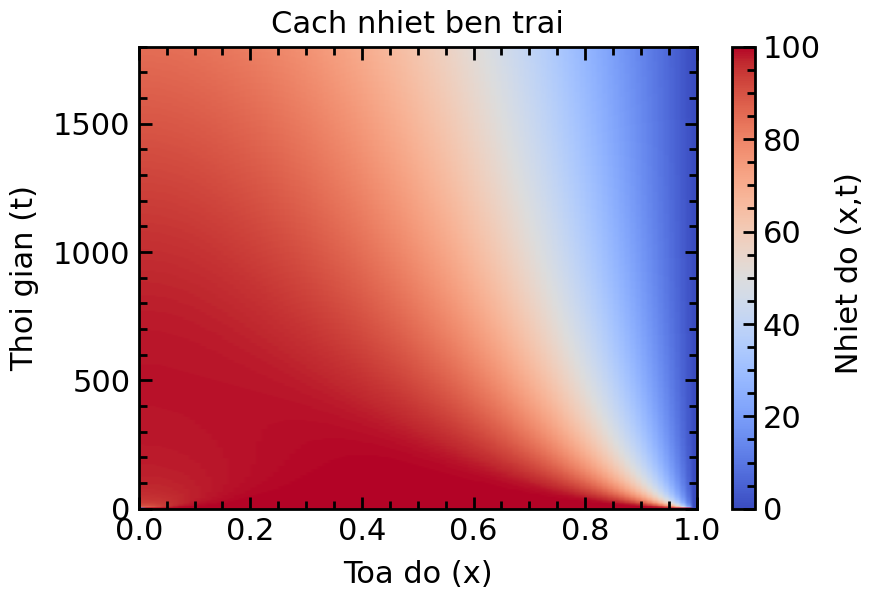

In [12]:
plt.figure(figsize=(9, 6))

plt.imshow(
    temp_forward_trai,
    extent=[x_forward_trai.min(), x_forward_trai.max(), t_forward_trai.min(), t_forward_trai.max()],
    origin="lower",
    aspect="auto",
    cmap = "coolwarm"
)

plt.xlabel("Toa do (x)")
plt.ylabel("Thoi gian (t)")
plt.title("Cach nhiet ben trai")
plt.colorbar(label=" Nhiet do (x,t)")
plt.savefig("BT2_cachnhiet_trai_forward_result.png", dpi =300)
plt.show()

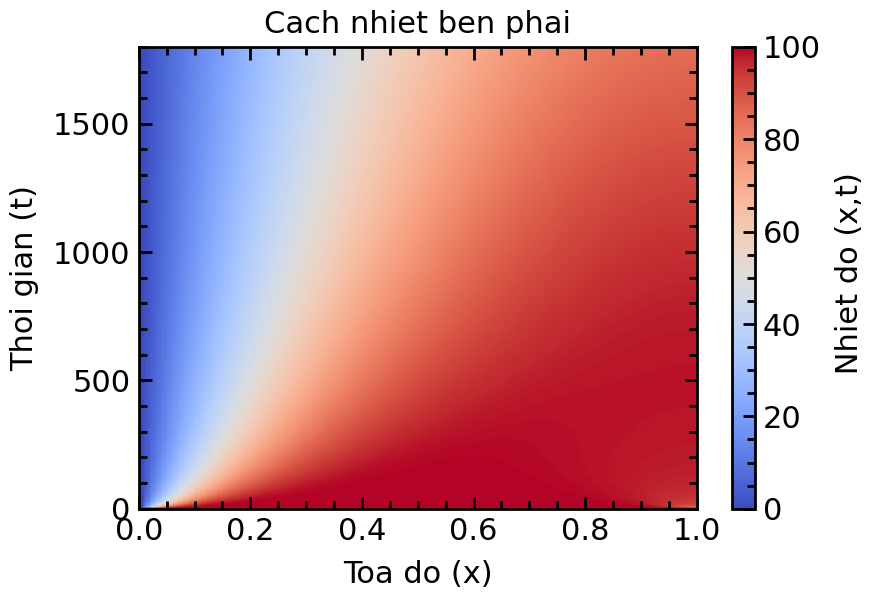

In [13]:
plt.figure(figsize=(9, 6))

plt.imshow(
    temp_forward_phai,
    extent=[x_forward_phai.min(), x_forward_phai.max(), t_forward_phai.min(), t_forward_phai.max()],
    origin="lower",
    aspect="auto",
    cmap = "coolwarm"
)

plt.xlabel("Toa do (x)")
plt.ylabel("Thoi gian (t)")
plt.title("Cach nhiet ben phai")
plt.colorbar(label=" Nhiet do (x,t)")
plt.savefig("BT2_cachnhiet_phai_forward_result.png", dpi =300)
plt.show()

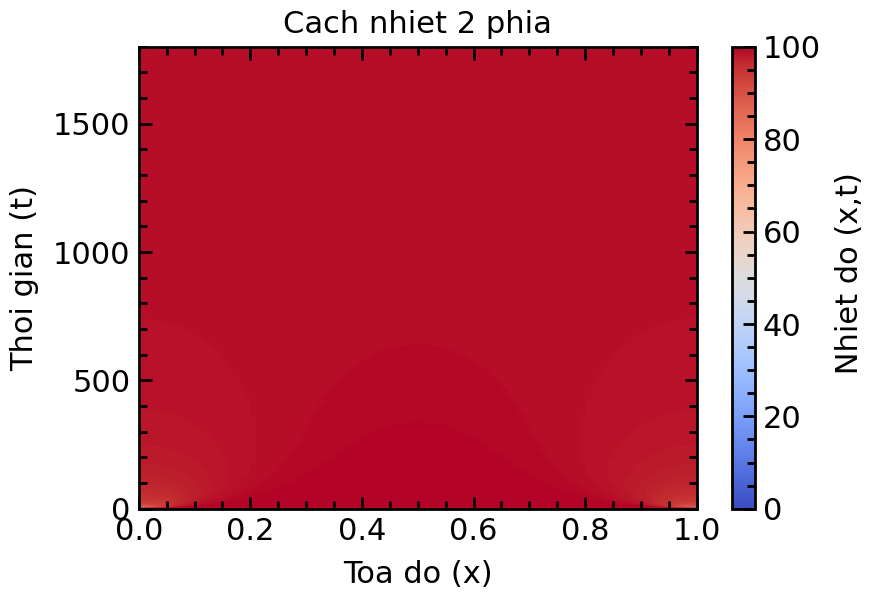

In [14]:
plt.figure(figsize=(9, 6))

plt.imshow(
    temp_forward_2phia,
    extent=[x_forward_2phia.min(), x_forward_2phia.max(), t_forward_2phia.min(), t_forward_2phia.max()],
    origin="lower",
    aspect="auto",
    cmap = "coolwarm"
)

plt.xlabel("Toa do (x)")
plt.ylabel("Thoi gian (t)")
plt.title("Cach nhiet 2 phia")
plt.colorbar(label=" Nhiet do (x,t)")
plt.savefig("BT2_cachnhiet_2phia_forward_result.png", dpi =300)
plt.show()